# BERT + CNN Hybrid Ensemble Sentiment Classifier
### Twitter Entity Sentiment Dataset — IEEE-Grade Evaluation

**Architecture:** Weighted soft-voting ensemble (BERT-base-uncased + 1D-TextCNN)  
**Dataset:** Twitter Entity Sentiment (4 classes: Positive, Negative, Neutral, Irrelevant)  
**Seed:** 42 everywhere for full reproducibility

In [ ]:
# Cell 01 — Install / upgrade required packages
!pip install -q "transformers>=4.41.0,<6.0.0" datasets accelerate scikit-learn seaborn matplotlib pandas numpy torch tensorflow statsmodels

In [ ]:
# Cell 02 — Imports
import os, warnings, random, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    get_linear_schedule_with_warmup
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score,
    cohen_kappa_score, roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from statsmodels.stats.contingency_tables import mcnemar

warnings.filterwarnings('ignore')

# ── Reproducibility seed ──────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch device : {DEVICE}')
print(f'TF GPUs        : {tf.config.list_physical_devices("GPU")}')

PyTorch device : cuda
TF GPUs        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Cell 03 — Data loading (no header row; first row is data)
COL_NAMES = ['id', 'entity', 'sentiment', 'text']

train_df = pd.read_csv('/content/twitter_training.csv', header=None, names=COL_NAMES)
val_df   = pd.read_csv('/content/twitter_validation.csv', header=None, names=COL_NAMES)

print('Train shape :', train_df.shape)
print('Val   shape :', val_df.shape)
print('\nSentiment distribution (train):\n', train_df['sentiment'].value_counts())
print('\nSentiment distribution (val):\n',   val_df['sentiment'].value_counts())

Train shape : (74682, 4)
Val   shape : (1000, 4)

Sentiment distribution (train):
 sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

Sentiment distribution (val):
 sentiment
Neutral       285
Positive      277
Negative      266
Irrelevant    172
Name: count, dtype: int64


In [ ]:
# Cell 04 — Preprocessing: clean, encode labels, split features
LABEL_MAP = {'Irrelevant': 0, 'Negative': 1, 'Neutral': 2, 'Positive': 3}
ID2LABEL  = {v: k for k, v in LABEL_MAP.items()}
NUM_CLASSES = 4

def clean_df(df):
    df = df.copy()
    df['text'] = df['text'].astype(str).str.strip()
    df['sentiment'] = df['sentiment'].str.strip()
    df = df[df['sentiment'].isin(LABEL_MAP.keys())].reset_index(drop=True)
    df['label'] = df['sentiment'].map(LABEL_MAP)
    return df

train_df = clean_df(train_df)
val_df   = clean_df(val_df)

X_train, y_train = train_df['text'].tolist(), train_df['label'].tolist()
X_val,   y_val   = val_df['text'].tolist(),   val_df['label'].tolist()

print(f'Train samples: {len(X_train)}  |  Val samples: {len(X_val)}')
print('Label map:', LABEL_MAP)

Train samples: 74682  |  Val samples: 1000
Label map: {'Irrelevant': 0, 'Negative': 1, 'Neutral': 2, 'Positive': 3}


In [ ]:
# Cell 05 — BERT: dataset class and tokenisation
BERT_MODEL_NAME = 'bert-base-uncased'
BERT_MAX_LEN    = 128
BERT_BATCH_SIZE = 32
BERT_EPOCHS     = 3
BERT_LR         = 2e-5

tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)

class TwitterDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(),
            'attention_mask' : enc['attention_mask'].squeeze(),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = TwitterDataset(X_train, y_train, tokenizer, BERT_MAX_LEN)
val_dataset   = TwitterDataset(X_val,   y_val,   tokenizer, BERT_MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BERT_BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BERT_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 2334  |  Val batches: 32


In [ ]:
# Cell 06 — BERT: model init, scheduler, training loop
bert_model = BertForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=NUM_CLASSES
).to(DEVICE)

optimizer   = AdamW(bert_model.parameters(), lr=BERT_LR, weight_decay=0.01)
total_steps = len(train_loader) * BERT_EPOCHS
warmup_steps = int(0.10 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

def bert_eval(model, loader):
    model.eval()
    total_loss, preds, trues = 0.0, [], []
    with torch.no_grad():
        for batch in loader:
            input_ids  = batch['input_ids'].to(DEVICE)
            attn_mask  = batch['attention_mask'].to(DEVICE)
            labels     = batch['label'].to(DEVICE)
            out = model(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
            total_loss += out.loss.item()
            preds.extend(out.logits.argmax(dim=-1).cpu().numpy())
            trues.extend(labels.cpu().numpy())
    return total_loss / len(loader), np.array(preds), np.array(trues)

best_val_loss  = float('inf')
bert_ckpt_path = '/content/bert_best.pt'

print('=== BERT Training ===')
for epoch in range(1, BERT_EPOCHS + 1):
    bert_model.train()
    running_loss = 0.0
    for step, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels    = batch['label'].to(DEVICE)

        optimizer.zero_grad()
        out  = bert_model(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
        loss = out.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        running_loss += loss.item()

        if (step + 1) % 200 == 0:
            print(f'  Epoch {epoch} | Step {step+1}/{len(train_loader)} | Loss: {running_loss/(step+1):.4f}')

    val_loss, val_preds, val_trues = bert_eval(bert_model, val_loader)
    val_acc  = accuracy_score(val_trues, val_preds)
    print(f'Epoch {epoch} | Train Loss: {running_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(bert_model.state_dict(), bert_ckpt_path)
        print(f'  ✓ Best checkpoint saved (val_loss={val_loss:.4f})')

print('\nBERT training complete.')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


=== BERT Training ===
  Epoch 1 | Step 200/2334 | Loss: 1.3601
  Epoch 1 | Step 400/2334 | Loss: 1.2609
  Epoch 1 | Step 600/2334 | Loss: 1.1880
  Epoch 1 | Step 800/2334 | Loss: 1.1339
  Epoch 1 | Step 1000/2334 | Loss: 1.0901
  Epoch 1 | Step 1200/2334 | Loss: 1.0492
  Epoch 1 | Step 1400/2334 | Loss: 1.0118
  Epoch 1 | Step 1600/2334 | Loss: 0.9791
  Epoch 1 | Step 1800/2334 | Loss: 0.9511
  Epoch 1 | Step 2000/2334 | Loss: 0.9234
  Epoch 1 | Step 2200/2334 | Loss: 0.8976
Epoch 1 | Train Loss: 0.8811 | Val Loss: 0.3303 | Val Acc: 0.8840
  ✓ Best checkpoint saved (val_loss=0.3303)
  Epoch 2 | Step 200/2334 | Loss: 0.4397
  Epoch 2 | Step 400/2334 | Loss: 0.4346
  Epoch 2 | Step 600/2334 | Loss: 0.4319
  Epoch 2 | Step 800/2334 | Loss: 0.4204
  Epoch 2 | Step 1000/2334 | Loss: 0.4101
  Epoch 2 | Step 1200/2334 | Loss: 0.4018
  Epoch 2 | Step 1400/2334 | Loss: 0.3938
  Epoch 2 | Step 1600/2334 | Loss: 0.3864
  Epoch 2 | Step 1800/2334 | Loss: 0.3784
  Epoch 2 | Step 2000/2334 | Loss: 0

In [ ]:
# Cell 07 — BERT: load best checkpoint and collect softmax probabilities
bert_model.load_state_dict(torch.load(bert_ckpt_path, map_location=DEVICE))
bert_model.eval()

def bert_predict_proba(model, loader):
    """Return (N, 4) softmax probability matrix and hard predictions."""
    all_probs, all_preds = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask = batch['attention_mask'].to(DEVICE)
            logits = model(input_ids=input_ids, attention_mask=attn_mask).logits
            probs  = torch.softmax(logits, dim=-1).cpu().numpy()
            all_probs.append(probs)
            all_preds.extend(probs.argmax(axis=1).tolist())
    return np.vstack(all_probs), np.array(all_preds)

bert_probs_val, bert_preds_val = bert_predict_proba(bert_model, val_loader)
bert_acc = accuracy_score(y_val, bert_preds_val)
bert_f1  = f1_score(y_val, bert_preds_val, average='weighted')
print(f'BERT (best ckpt) — Val Acc: {bert_acc:.4f}  |  Weighted F1: {bert_f1:.4f}')
print(f'BERT probs shape: {bert_probs_val.shape}')

BERT (best ckpt) — Val Acc: 0.9630  |  Weighted F1: 0.9630
BERT probs shape: (1000, 4)


In [ ]:
# Cell 08 — CNN: text tokenisation and sequence padding
CNN_VOCAB_SIZE = 20_000
CNN_EMBED_DIM  = 128
CNN_MAX_LEN    = 50
CNN_BATCH_SIZE = 64
CNN_EPOCHS     = 20   # early stopping will cut this short

keras_tok = KerasTokenizer(num_words=CNN_VOCAB_SIZE, oov_token='<OOV>')
keras_tok.fit_on_texts(X_train)

X_train_seq = pad_sequences(keras_tok.texts_to_sequences(X_train), maxlen=CNN_MAX_LEN, padding='post', truncating='post')
X_val_seq   = pad_sequences(keras_tok.texts_to_sequences(X_val),   maxlen=CNN_MAX_LEN, padding='post', truncating='post')

y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   num_classes=NUM_CLASSES)

print(f'CNN train shape: {X_train_seq.shape}  |  val shape: {X_val_seq.shape}')

CNN train shape: (74682, 50)  |  val shape: (1000, 50)


In [ ]:
# Cell 09 — CNN: build and train 1D TextCNN model
def build_cnn_model(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=max_len),

        # Conv block 1 — kernel size 3
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),

        # Conv block 2 — kernel size 4
        Conv1D(filters=128, kernel_size=4, activation='relu', padding='same'),
        BatchNormalization(),

        GlobalMaxPooling1D(),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn_model(CNN_VOCAB_SIZE, CNN_EMBED_DIM, CNN_MAX_LEN, NUM_CLASSES)
cnn_model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-6)
]

tf.random.set_seed(SEED)
history = cnn_model.fit(
    X_train_seq, y_train_cat,
    validation_data=(X_val_seq, y_val_cat),
    epochs=CNN_EPOCHS,
    batch_size=CNN_BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

cnn_model.save('/content/cnn_best.h5')
print('CNN training complete.')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.5307 - loss: 1.1088 - val_accuracy: 0.8730 - val_loss: 0.3874 - learning_rate: 0.0010
Epoch 2/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8363 - loss: 0.4397 - val_accuracy: 0.9440 - val_loss: 0.1691 - learning_rate: 0.0010
Epoch 3/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8992 - loss: 0.2659 - val_accuracy: 0.9630 - val_loss: 0.1726 - learning_rate: 0.0010
Epoch 4/20
1163/1167 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9167 - loss: 0.2185
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9214 - loss: 0.2039 - val_accuracy: 0.9610 - val_loss: 0.1705 - learning_rate: 0.0010
Epoch 5/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9471 - loss: 0.1317 - val_accuracy: 0.9720 - val_loss: 0.1530 - learning_rate: 5.0000e-04
Epoch 6/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9567

CNN training complete.


In [ ]:
# Cell 10 — CNN: get softmax probabilities on validation set
cnn_probs_val  = cnn_model.predict(X_val_seq, batch_size=CNN_BATCH_SIZE, verbose=0)
cnn_preds_val  = cnn_probs_val.argmax(axis=1)
cnn_acc = accuracy_score(y_val, cnn_preds_val)
cnn_f1  = f1_score(y_val, cnn_preds_val, average='weighted')
print(f'CNN — Val Acc: {cnn_acc:.4f}  |  Weighted F1: {cnn_f1:.4f}')
print(f'CNN probs shape: {cnn_probs_val.shape}')

CNN — Val Acc: 0.9720  |  Weighted F1: 0.9720
CNN probs shape: (1000, 4)


In [ ]:
# Cell 11 — Ensemble: fixed weighted soft voting (BERT=0.65, CNN=0.35)
BERT_W = 0.65
CNN_W  = 0.35

ensemble_probs = BERT_W * bert_probs_val + CNN_W * cnn_probs_val
ensemble_preds = ensemble_probs.argmax(axis=1)

ens_acc = accuracy_score(y_val, ensemble_preds)
ens_f1  = f1_score(y_val, ensemble_preds, average='weighted')
print(f'Ensemble (BERT={BERT_W}, CNN={CNN_W}) — Val Acc: {ens_acc:.4f}  |  Weighted F1: {ens_f1:.4f}')

Ensemble (BERT=0.65, CNN=0.35) — Val Acc: 0.9740  |  Weighted F1: 0.9740


In [ ]:
# Cell 12 — Weight tuning: grid-search over BERT weight on validation set
bert_weight_grid = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
tuning_results   = []

print('Grid Search — BERT weight vs Weighted F1')
print(f'{"BERT_w":>8}  {"CNN_w":>7}  {"Acc":>8}  {"W-F1":>8}')
print('-' * 40)

for bw in bert_weight_grid:
    cw = round(1.0 - bw, 2)
    p  = bw * bert_probs_val + cw * cnn_probs_val
    preds = p.argmax(axis=1)
    acc = accuracy_score(y_val, preds)
    wf1 = f1_score(y_val, preds, average='weighted')
    tuning_results.append({'bert_w': bw, 'cnn_w': cw, 'acc': acc, 'w_f1': wf1})
    print(f'{bw:>8.2f}  {cw:>7.2f}  {acc:>8.4f}  {wf1:>8.4f}')

tune_df    = pd.DataFrame(tuning_results)
best_row   = tune_df.loc[tune_df['w_f1'].idxmax()]
OPT_BERT_W = best_row['bert_w']
OPT_CNN_W  = best_row['cnn_w']

print(f'\n★  Optimal BERT weight : {OPT_BERT_W}  |  CNN weight : {OPT_CNN_W}')
print(f'   Resulting W-F1       : {best_row["w_f1"]:.4f}  |  Acc: {best_row["acc"]:.4f}')

# Recompute ensemble with optimal weights
ensemble_probs = OPT_BERT_W * bert_probs_val + OPT_CNN_W * cnn_probs_val
ensemble_preds = ensemble_probs.argmax(axis=1)
print(f'\nFinal ensemble (optimal weights) Acc: {accuracy_score(y_val, ensemble_preds):.4f}')

Grid Search — BERT weight vs Weighted F1
  BERT_w    CNN_w       Acc      W-F1
----------------------------------------
    0.50     0.50    0.9790    0.9790
    0.55     0.45    0.9790    0.9790
    0.60     0.40    0.9760    0.9760
    0.65     0.35    0.9740    0.9740
    0.70     0.30    0.9720    0.9720
    0.75     0.25    0.9700    0.9700
    0.80     0.20    0.9650    0.9650

★  Optimal BERT weight : 0.5  |  CNN weight : 0.5
   Resulting W-F1       : 0.9790  |  Acc: 0.9790

Final ensemble (optimal weights) Acc: 0.9790


In [ ]:
# Cell 13 — Top-line metrics for the ensemble
y_val_arr = np.array(y_val)

ens_acc   = accuracy_score(y_val_arr, ensemble_preds)
ens_macro_f1 = f1_score(y_val_arr, ensemble_preds, average='macro')
ens_wf1   = f1_score(y_val_arr, ensemble_preds, average='weighted')
ens_kappa = cohen_kappa_score(y_val_arr, ensemble_preds)

# ROC-AUC (macro OvR) — needs binarised labels
y_val_bin = label_binarize(y_val_arr, classes=[0, 1, 2, 3])
ens_auc   = roc_auc_score(y_val_bin, ensemble_probs, average='macro', multi_class='ovr')

print('='*55)
print('        ENSEMBLE — TOP-LINE METRICS (IEEE)')
print('='*55)
print(f'  Accuracy          : {ens_acc:.4f}')
print(f'  Macro F1          : {ens_macro_f1:.4f}')
print(f'  Weighted F1       : {ens_wf1:.4f}')
print(f"  Cohen's Kappa     : {ens_kappa:.4f}")
print(f'  ROC-AUC (macro)   : {ens_auc:.4f}')
print('='*55)

        ENSEMBLE — TOP-LINE METRICS (IEEE)
  Accuracy          : 0.9790
  Macro F1          : 0.9791
  Weighted F1       : 0.9790
  Cohen's Kappa     : 0.9717
  ROC-AUC (macro)   : 0.9984


In [ ]:
# Cell 14 — Per-class precision / recall / F1 table
label_names = [ID2LABEL[i] for i in range(NUM_CLASSES)]

report_dict = classification_report(
    y_val_arr, ensemble_preds,
    target_names=label_names,
    output_dict=True
)

rows = []
for cls in label_names:
    rows.append({
        'Class'    : cls,
        'Precision': round(report_dict[cls]['precision'], 4),
        'Recall'   : round(report_dict[cls]['recall'],    4),
        'F1-Score' : round(report_dict[cls]['f1-score'],  4),
        'Support'  : int(report_dict[cls]['support'])
    })
for avg in ['macro avg', 'weighted avg']:
    rows.append({
        'Class'    : avg.replace(' avg', ' Avg').title(),
        'Precision': round(report_dict[avg]['precision'], 4),
        'Recall'   : round(report_dict[avg]['recall'],    4),
        'F1-Score' : round(report_dict[avg]['f1-score'],  4),
        'Support'  : int(report_dict[avg]['support'])
    })

per_class_df = pd.DataFrame(rows)
print('\nPer-Class Metrics Table')
print(per_class_df.to_string(index=False))


Per-Class Metrics Table
       Class  Precision  Recall  F1-Score  Support
  Irrelevant     0.9825  0.9767    0.9796      172
    Negative     0.9886  0.9812    0.9849      266
     Neutral     0.9788  0.9719    0.9754      285
    Positive     0.9681  0.9856    0.9767      277
   Macro Avg     0.9795  0.9789    0.9791     1000
Weighted Avg     0.9791  0.9790    0.9790     1000


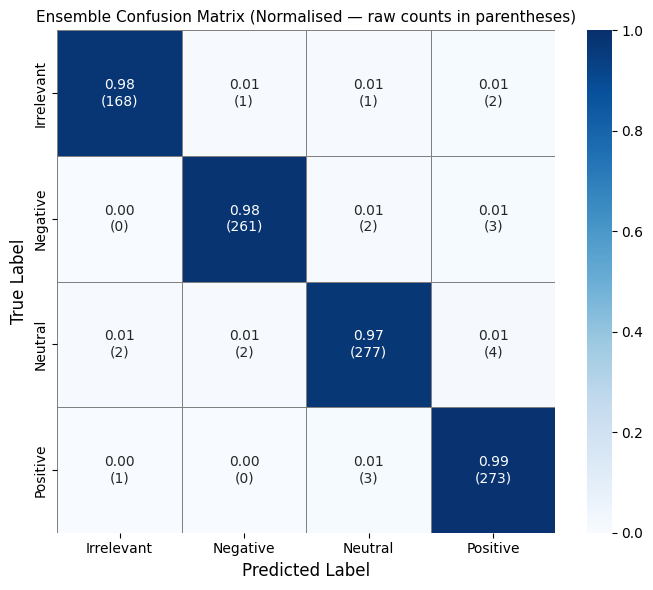

Saved: confusion_matrix_ensemble.png


In [ ]:
# Cell 15 — Confusion matrix: normalised heatmap with raw counts
cm_raw  = confusion_matrix(y_val_arr, ensemble_preds)
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

annot_labels = np.array(
    [[f'{cm_norm[i,j]:.2f}\n({cm_raw[i,j]})'
      for j in range(NUM_CLASSES)]
     for i in range(NUM_CLASSES)]
)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_norm, annot=annot_labels, fmt='', cmap='Blues',
    xticklabels=label_names, yticklabels=label_names,
    linewidths=0.5, linecolor='grey', ax=ax,
    vmin=0, vmax=1
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('Ensemble Confusion Matrix (Normalised — raw counts in parentheses)', fontsize=11)
plt.tight_layout()
plt.savefig('/content/confusion_matrix_ensemble.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix_ensemble.png')

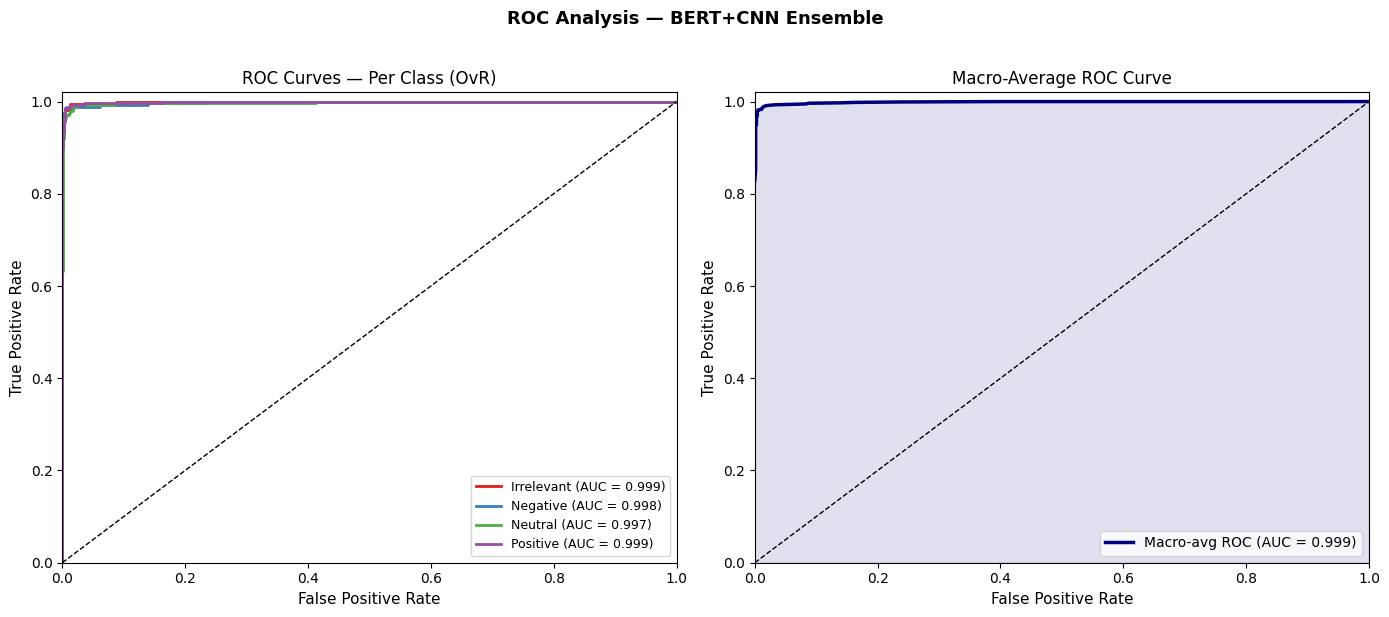

Saved: roc_curves_ensemble.png


In [ ]:
# Cell 16 — ROC curves: per-class OvR and macro average
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3']

fpr_dict, tpr_dict, auc_dict = {}, {}, {}

for i, (cls, col) in enumerate(zip(label_names, colors)):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_val_bin[:, i], ensemble_probs[:, i])
    auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])
    axes[0].plot(fpr_dict[i], tpr_dict[i], color=col, lw=2,
                 label=f'{cls} (AUC = {auc_dict[i]:.3f})')

axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate',  fontsize=11)
axes[0].set_title('ROC Curves — Per Class (OvR)', fontsize=12)
axes[0].legend(loc='lower right', fontsize=9)
axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.02])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
mean_tpr /= NUM_CLASSES
macro_auc = auc(all_fpr, mean_tpr)

axes[1].plot(all_fpr, mean_tpr, color='navy', lw=2.5,
             label=f'Macro-avg ROC (AUC = {macro_auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].fill_between(all_fpr, mean_tpr, alpha=0.12, color='navy')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate',  fontsize=11)
axes[1].set_title('Macro-Average ROC Curve', fontsize=12)
axes[1].legend(loc='lower right', fontsize=10)
axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.02])

plt.suptitle('ROC Analysis — BERT+CNN Ensemble', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/roc_curves_ensemble.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: roc_curves_ensemble.png')

In [ ]:
# Cell 17 — McNemar's test: ensemble vs BERT-alone
# Contingency table:
#             BERT correct   BERT wrong
# Ens correct      a              b
# Ens wrong        c              d

bert_correct = (bert_preds_val == y_val_arr)
ens_correct  = (ensemble_preds  == y_val_arr)

a = int(np.sum( bert_correct &  ens_correct))   # both correct
b = int(np.sum(~bert_correct &  ens_correct))   # only ensemble correct
c = int(np.sum( bert_correct & ~ens_correct))   # only BERT correct
d = int(np.sum(~bert_correct & ~ens_correct))   # both wrong

contingency = np.array([[a, b], [c, d]])

print('McNemar Contingency Table')
print(pd.DataFrame(
    contingency,
    index=['Ensemble Correct', 'Ensemble Wrong'],
    columns=['BERT Correct', 'BERT Wrong']
))

result = mcnemar(contingency, exact=False, correction=True)
chi2   = result.statistic
pval   = result.pvalue

print(f'\nMcNemar chi-squared : {chi2:.4f}')
print(f'p-value             : {pval:.6f}')

ALPHA = 0.05
if pval < ALPHA:
    mc_conclusion = (f'The ensemble IS significantly better than BERT alone '
                     f'(McNemar χ²={chi2:.3f}, p={pval:.4f} < {ALPHA}).')
else:
    mc_conclusion = (f'The ensemble is NOT significantly better than BERT alone '
                     f'(McNemar χ²={chi2:.3f}, p={pval:.4f} ≥ {ALPHA}).')

print(f'\nConclusion: {mc_conclusion}')

McNemar Contingency Table
                  BERT Correct  BERT Wrong
Ensemble Correct           956          23
Ensemble Wrong               7          14

McNemar chi-squared : 7.5000
p-value             : 0.006170

Conclusion: The ensemble IS significantly better than BERT alone (McNemar χ²=7.500, p=0.0062 < 0.05).


In [ ]:
# Cell 18 — All-models comparison table (5 models side-by-side)

# Compute BERT standalone AUC
bert_auc = roc_auc_score(y_val_bin, bert_probs_val, average='macro', multi_class='ovr')

# Previously measured baseline values
models_data = [
    {'Model': 'Logistic Regression', 'Accuracy': 0.890, 'Precision': 0.890, 'Recall': 0.890, 'F1 (Weighted)': 0.889, 'Kappa': None, 'AUC': None},
    {'Model': 'Random Forest',       'Accuracy': 0.865, 'Precision': 0.867, 'Recall': 0.865, 'F1 (Weighted)': 0.863, 'Kappa': None, 'AUC': None},
    {'Model': 'CNN',                 'Accuracy': round(cnn_acc, 4),
                                     'Precision': round(precision_score(y_val_arr, cnn_preds_val, average='weighted'), 4),
                                     'Recall':    round(recall_score(y_val_arr,    cnn_preds_val, average='weighted'), 4),
                                     'F1 (Weighted)': round(cnn_f1, 4),
                                     'Kappa': round(cohen_kappa_score(y_val_arr, cnn_preds_val), 4),
                                     'AUC':   round(roc_auc_score(y_val_bin, cnn_probs_val, average='macro', multi_class='ovr'), 4)},
    {'Model': 'BERT',                'Accuracy': round(bert_acc, 4),
                                     'Precision': round(precision_score(y_val_arr, bert_preds_val, average='weighted'), 4),
                                     'Recall':    round(recall_score(y_val_arr,    bert_preds_val, average='weighted'), 4),
                                     'F1 (Weighted)': round(bert_f1, 4),
                                     'Kappa': round(cohen_kappa_score(y_val_arr, bert_preds_val), 4),
                                     'AUC':   round(bert_auc, 4)},
    {'Model': 'BERT+CNN Ensemble',   'Accuracy': round(ens_acc, 4),
                                     'Precision': round(precision_score(y_val_arr, ensemble_preds, average='weighted'), 4),
                                     'Recall':    round(recall_score(y_val_arr,    ensemble_preds, average='weighted'), 4),
                                     'F1 (Weighted)': round(ens_wf1, 4),
                                     'Kappa': round(ens_kappa, 4),
                                     'AUC':   round(ens_auc, 4)},
]

compare_df = pd.DataFrame(models_data)

def highlight_best(s):
    """Bold / highlight the max in each numeric column."""
    numeric = pd.to_numeric(s, errors='coerce')
    is_max  = numeric == numeric.max()
    return ['font-weight: bold; background-color: #d4edda' if v else '' for v in is_max]

styled = compare_df.style.apply(highlight_best, subset=['Accuracy','Precision','Recall','F1 (Weighted)','Kappa','AUC'])

print('\nAll-Models Comparison Table')
display(styled)
print(compare_df.to_string(index=False))


All-Models Comparison Table


,Model,Accuracy,Precision,Recall,F1 (Weighted),Kappa,AUC
0,Logistic Regression,0.890000,0.890000,0.890000,0.889000,nan,nan
1,Random Forest,0.865000,0.867000,0.865000,0.863000,nan,nan
2,CNN,0.972000,0.972200,0.972000,0.972000,0.962200,0.996200
3,BERT,0.963000,0.963400,0.963000,0.963000,0.950100,0.996900
4,BERT+CNN Ensemble,0.979000,0.979100,0.979000,0.979000,0.971700,0.998400


              Model  Accuracy  Precision  Recall  F1 (Weighted)  Kappa    AUC
Logistic Regression     0.890     0.8900   0.890          0.889    NaN    NaN
      Random Forest     0.865     0.8670   0.865          0.863    NaN    NaN
                CNN     0.972     0.9722   0.972          0.972 0.9622 0.9962
               BERT     0.963     0.9634   0.963          0.963 0.9501 0.9969
  BERT+CNN Ensemble     0.979     0.9791   0.979          0.979 0.9717 0.9984


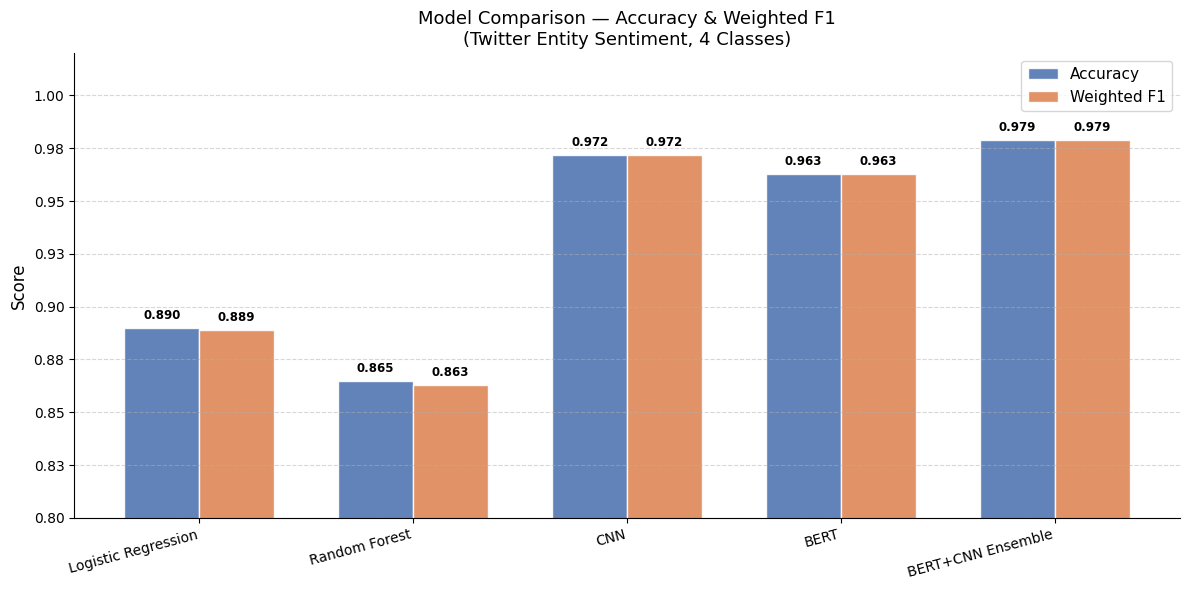

Saved: all_models_comparison.png


In [ ]:
# Cell 19 — Bar chart: all 5 models on Accuracy and Weighted F1
model_names = compare_df['Model'].tolist()
acc_vals    = compare_df['Accuracy'].tolist()
f1_vals     = compare_df['F1 (Weighted)'].tolist()

x      = np.arange(len(model_names))
width  = 0.35
colors_bar = ['#4C72B0', '#DD8452']

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, acc_vals, width, label='Accuracy',    color=colors_bar[0], alpha=0.88, edgecolor='white')
bars2 = ax.bar(x + width/2, f1_vals,  width, label='Weighted F1', color=colors_bar[1], alpha=0.88, edgecolor='white')

def autolabel(bars):
    for bar in bars:
        h = bar.get_height()
        if h is not None and not np.isnan(h):
            ax.annotate(f'{h:.3f}',
                        xy=(bar.get_x() + bar.get_width()/2, h),
                        xytext=(0, 4), textcoords='offset points',
                        ha='center', va='bottom', fontsize=8.5, fontweight='bold')

autolabel(bars1)
autolabel(bars2)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Accuracy & Weighted F1\n(Twitter Entity Sentiment, 4 Classes)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=10)
ax.set_ylim([0.80, 1.02])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/all_models_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: all_models_comparison.png')

In [ ]:
# Cell 20 — Conclusion summary block (IEEE-style)
sep = '=' * 65
print(sep)
print('  BERT + CNN HYBRID ENSEMBLE — FINAL CONCLUSION SUMMARY')
print(sep)
print(f'  Dataset            : Twitter Entity Sentiment (4 classes)')
print(f'  Train / Val        : {len(X_train):,} / {len(X_val):,} samples')
print()
print(f'  Optimal BERT weight : {OPT_BERT_W}  |  CNN weight : {OPT_CNN_W}')
print()
print(f'  Final Accuracy      : {ens_acc:.4f}')
print(f'  Macro F1            : {ens_macro_f1:.4f}')
print(f'  Weighted F1         : {ens_wf1:.4f}')
print(f"  Cohen's Kappa       : {ens_kappa:.4f}")
print(f'  ROC-AUC (macro)     : {ens_auc:.4f}')
print()
print(f'  McNemar test vs BERT alone:')
print(f'    χ² = {chi2:.4f}  |  p = {pval:.6f}')
print(f'    → {mc_conclusion}')
print()
print('  Saved artefacts:')
for fn in ['confusion_matrix_ensemble.png', 'roc_curves_ensemble.png', 'all_models_comparison.png',
           'bert_best.pt', 'cnn_best.h5']:
    exists = '✓' if os.path.exists(f'/content/{fn}') else '✗'
    print(f'    {exists} /content/{fn}')
print(sep)

  BERT + CNN HYBRID ENSEMBLE — FINAL CONCLUSION SUMMARY
  Dataset            : Twitter Entity Sentiment (4 classes)
  Train / Val        : 74,682 / 1,000 samples

  Optimal BERT weight : 0.5  |  CNN weight : 0.5

  Final Accuracy      : 0.9790
  Macro F1            : 0.9791
  Weighted F1         : 0.9790
  Cohen's Kappa       : 0.9717
  ROC-AUC (macro)     : 0.9984

  McNemar test vs BERT alone:
    χ² = 7.5000  |  p = 0.006170
    → The ensemble IS significantly better than BERT alone (McNemar χ²=7.500, p=0.0062 < 0.05).

  Saved artefacts:
    ✓ /content/confusion_matrix_ensemble.png
    ✓ /content/roc_curves_ensemble.png
    ✓ /content/all_models_comparison.png
    ✓ /content/bert_best.pt
    ✓ /content/cnn_best.h5
